ONEMAX - AG com 30 indivíduos, 50 gerações
Geração   0: Melhor = 15/20, Média = 10.10
Geração  10: Melhor = 20/20, Média = 19.00
Geração  20: Melhor = 20/20, Média = 19.83
Geração  30: Melhor = 20/20, Média = 19.70
Geração  40: Melhor = 20/20, Média = 19.63

 MELHOR FITNESS: 20/20
   Ótimo = 20 (todos os bits são 1)


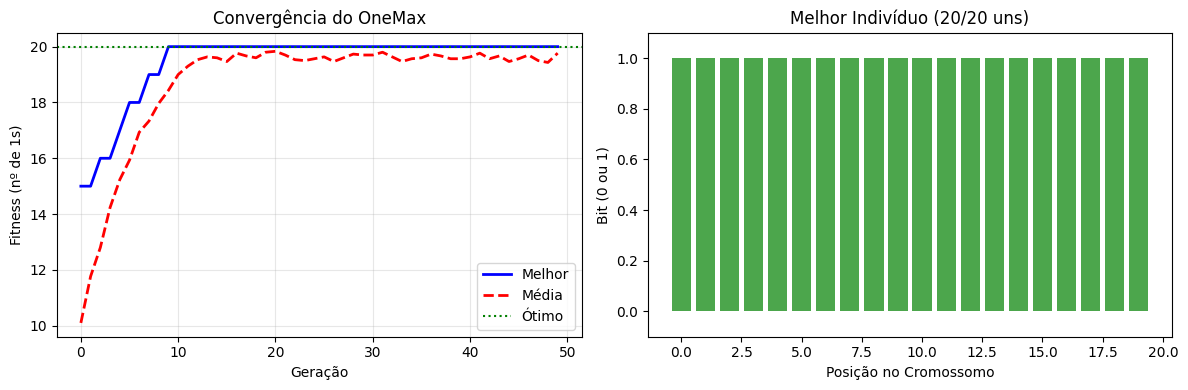

In [3]:
import random
import matplotlib.pyplot as plt
import numpy as np

TAMANHO = 20
def fitness(individuo):
    """OneMax: contar quantos 1s tem."""
    return sum(individuo)

def criar_individuo():
    return [random.randint(0, 1) for _ in range(TAMANHO)]

def criar_populacao():
    return [criar_individuo() for _ in range(POPULACAO)]

def selecao_torneio(pop, fitnesses):
    """Escolhe o melhor entre 3 aleatórios."""
    candidatos = random.sample(range(len(pop)), 3)
    melhor = max(candidatos, key=lambda i: fitnesses[i])
    return pop[melhor].copy()

def crossover(pai1, pai2):
    if random.random() > TAXA_CROSS:
        return pai1.copy(), pai2.copy()

    ponto = random.randint(1, TAMANHO - 1)
    filho1 = pai1[:ponto] + pai2[ponto:]
    filho2 = pai2[:ponto] + pai1[ponto:]
    return filho1, filho2

def mutacao(ind):
    for i in range(len(ind)):
        if random.random() < TAXA_MUT:
            ind[i] = 1 - ind[i]
    return ind


print("=" * 50)
print(f"ONEMAX - AG com {POPULACAO} indivíduos, {GERACOES} gerações")
print("=" * 50)

pop = criar_populacao()
historico_melhor = []
historico_medio = []

for gen in range(GERACOES):

    fitnesses = [fitness(ind) for ind in pop]

    melhor = max(fitnesses)
    medio = sum(fitnesses) / POPULACAO
    historico_melhor.append(melhor)
    historico_medio.append(medio)

    if gen % 10 == 0:
        print(f"Geração {gen:3d}: Melhor = {melhor:2d}/{TAMANHO}, Média = {medio:.2f}")


    sorted_idx = np.argsort(fitnesses)[::-1]
    nova_pop = [pop[i].copy() for i in sorted_idx[:ELITE]]


    while len(nova_pop) < POPULACAO:
        pai1 = selecao_torneio(pop, fitnesses)
        pai2 = selecao_torneio(pop, fitnesses)
        filho1, filho2 = crossover(pai1, pai2)
        nova_pop.append(mutacao(filho1))
        if len(nova_pop) < POPULACAO:
            nova_pop.append(mutacao(filho2))

    pop = nova_pop

fitnesses = [fitness(ind) for ind in pop]
melhor = max(fitnesses)
print(f"\n MELHOR FITNESS: {melhor}/{TAMANHO}")
print(f"   Ótimo = {TAMANHO} (todos os bits são 1)")


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historico_melhor, 'b-', linewidth=2, label='Melhor')
plt.plot(historico_medio, 'r--', linewidth=2, label='Média')
plt.axhline(y=TAMANHO, color='g', linestyle=':', label='Ótimo')
plt.xlabel('Geração')
plt.ylabel('Fitness (nº de 1s)')
plt.title('Convergência do OneMax')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

melhor_ind = pop[fitnesses.index(max(fitnesses))]
cores = ['green' if bit == 1 else 'red' for bit in melhor_ind]
plt.bar(range(TAMANHO), melhor_ind, color=cores, alpha=0.7)
plt.xlabel('Posição no Cromossomo')
plt.ylabel('Bit (0 ou 1)')
plt.title(f'Melhor Indivíduo ({melhor}/{TAMANHO} uns)')
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()